In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import re


from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.datetime_handler import calc_rel_period
from lib.visualization.plot_generator import PlotGen

import matplotlib as mpl
import lib.visualization.font_setting as font_setting
mpl.rcParams.update(font_setting.fig_setting)

import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from adjustText import adjust_text  # pip install adjustText

from scipy.stats import spearmanr
from scipy import stats


In [2]:
def compute_N_by_week(lang, df, period_col='rel_week', weight_col='tot_pct'):
    N = df.groupby(period_col)[weight_col].sum().reset_index()
    N.columns = ["rel_week", "n_docs"]
    N["language"] = lang
    return N


In [3]:
panel = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    plotgen = PlotGen(idx = 100+idx, model_in_run='tag')
    print(f'[Start....] Aggreagate data for {lang} language')

    tmp = load_df(plotgen.data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    tmp = calc_rel_period(tmp, plotgen.std_date, date_col = 'cdate', period = 7).reset_index()
    tmp = compute_N_by_week(lang, tmp, weight_col='pct')
    panel = pd.concat([panel, tmp], axis = 0)
    

[Start....] Aggreagate data for python language
[Start....] Aggreagate data for javascript language
[Start....] Aggreagate data for java language
[Start....] Aggreagate data for c# language
[Start....] Aggreagate data for c++ language
[Start....] Aggreagate data for c language
[Start....] Aggreagate data for r language
[Start....] Aggreagate data for php language
[Start....] Aggreagate data for swift language
[Start....] Aggreagate data for kotlin language
[Start....] Aggreagate data for dart language
[Start....] Aggreagate data for typescript language
[Start....] Aggreagate data for go language
[Start....] Aggreagate data for ruby language
[Start....] Aggreagate data for rust language
[Start....] Aggreagate data for scala language
[Start....] Aggreagate data for julia language
[Start....] Aggreagate data for matlab language
[Start....] Aggreagate data for groovy language
[Start....] Aggreagate data for objective-c language
[Start....] Aggreagate data for vb.net language
[Start....] Ag

In [4]:
panel["post"]   = (panel["rel_week"] >= 0).astype(int)
panel["t"]      = panel["rel_week"]
panel["post_t"] = panel["post"] * panel["rel_week"]
panel["log_y"]  = np.log(panel["n_docs"] + 1)


In [5]:
formula = ("log_y ~ t + post + post_t "
           "+ C(language) + C(language):post + C(language):post_t")
print(formula)
m = smf.ols(formula, data=panel).fit(
    cov_type="cluster", cov_kwds={"groups": panel["language"]}
)
m.summary()

log_y ~ t + post + post_t + C(language) + C(language):post + C(language):post_t


/home/mghan/sopjt/git/so_data_availability/venv_so_data_availability/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 90, but rank is 1
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  log_y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     39.19
Date:                Sun, 17 May 2026   Prob (F-statistic):           7.82e-07
Time:                        14:44:12   Log-Likelihood:                -1280.1
No. Observations:                7628   AIC:                             2742.
Df Residuals:                    7537   BIC:                             3374.
Df Model:                          90                                         
Covariance Type:              cluster                                         
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             3.8514      0.040     97.441      0.000       3.774       3.929
C(language)[T.c]                      1.9286   4.03e-14   4.79e+13      0.000       1.929       1.929
C(language)[T.c#]                     3.0822   2.93e-14   1.05e+14      0.000       3.082       3.082
C(language)[T.c++]                    2.5795   2.78e-14   9.28e+13      0.000       2.580       2.580
C(language)[T.dart]                   1.8987   5.79e-14   3.28e+13      0.000       1.899       1.899
C(language)[T.delphi]                -0.6118   2.75e-14  -2.23e+13      0.000      -0.612      -0.612
C(language)[T.f#]                    -1.6871   3.43e-14  -4.91e+13      0.000      -1.687      -1.687
C(language)[T.fortran]               -1.4708   1.79e-13  -8.22e+12      0.000      -1.471      -1.471
C(language)[T.go]                     0.8849   6.81e-14    1.3e+13      0.000       0.885       0.885
C(language)[T.groovy]                -0.6304   1.98e-13  -3.18e+12      0.000      -0.630      -0.630
C(language)[T.haskell]               -0.5182    3.1e-13  -1.67e+12      0.000      -0.518      -0.518
C(language)[T.java]                   3.2685   3.17e-14   1.03e+14      0.000       3.268       3.268
C(language)[T.javascript]             4.0146   5.44e-14   7.37e+13      0.000       4.015       4.015
C(language)[T.julia]                 -0.6974   1.78e-13  -3.91e+12      0.000      -0.697      -0.697
C(language)[T.kotlin]                 1.6970   6.49e-14   2.61e+13      0.000       1.697       1.697
C(language)[T.lua]                   -0.6926   8.47e-14  -8.17e+12      0.000      -0.693      -0.693
C(language)[T.matlab]                -0.2979   1.64e-13  -1.81e+12      0.000      -0.298      -0.298
C(language)[T.objective-c]           -0.7189   3.11e-13  -2.31e+12      0.000      -0.719      -0.719
C(language)[T.perl]                  -0.9175   1.87e-13  -4.91e+12      0.000      -0.918      -0.918
C(language)[T.php]                    2.6560   2.69e-14   9.87e+13      0.000       2.656       2.656
C(language)[T.prolog]                -1.8865   3.39e-14  -5.57e+13      0.000      -1.887      -1.887
C(language)[T.python]                 4.3770   1.69e-13   2.59e+13      0.000       4.377       4.377
C(language)[T.r]                      2.7058   2.98e-14   9.09e+13      0.000       2.706       2.706
C(language)[T.ruby]                   0.5314   1.63e-13   3.26e+12      0.000       0.531       0.531
C(language)[T.rust]                   0.5545   4.65e-14   1.19e+13      0.000       0.554       0.554
C(language)[T.scala]                  0.3721   2.03e-13   1.83e+12      0.000       0.372       0.372
C(language)[T.solidity]              -0.5570    4.2e-14  -1.33e+13      0.000      -0.557      -0.557
C(language)[T.swift]   

In [6]:
pat_post = re.compile(r"C\(language\)\[T\.(.+?)\]:post$")
interaction_post = {pat_post.match(n).group(1): v 
                    for n, v in m.params.items() if pat_post.match(n)}

all_langs = list(panel["language"].unique())
baseline_lang = [l for l in all_langs if l not in interaction_post][0]

# 언어별 level effect (참고용)
effects = {baseline_lang: m.params["post"]}
for lang, inter in interaction_post.items():
    effects[lang] = m.params["post"] + inter
eff_series = pd.Series(effects)



In [7]:
pre_data = panel[panel["post"]==0].groupby("language")['n_docs'].sum().reset_index()
pre_data['log_n_docs'] = np.log(pre_data['n_docs'] + 1)

In [8]:

# ─────────────────────────────────────
# 5. ★ slope change (post_t) 추출 → slope_summary
# ─────────────────────────────────────
pat_post_t = re.compile(r"C\(language\)\[T\.(.+?)\]:post_t$")
interaction_post_t = {pat_post_t.match(n).group(1): v 
                      for n, v in m.params.items() if pat_post_t.match(n)}

# 각 언어의 총 slope change = baseline의 post_t + 해당 언어의 상호작용
slope_effects = {baseline_lang: m.params["post_t"]}
for lang, inter in interaction_post_t.items():
    slope_effects[lang] = m.params["post_t"] + inter

slope_df = pd.DataFrame(list(slope_effects.items()), columns=["language", "slope_change"])
slope_df['weekly_pct'] = (np.exp(slope_df['slope_change']) - 1) * 100
slope_summary = pd.merge(slope_df, pre_data, on="language")


In [9]:
x_vals = slope_summary["log_n_docs"]
y_vals = slope_summary["weekly_pct"]  # weekly % change (negative)
langs = slope_summary["language"]
df = pd.DataFrame({'x': x_vals, 'y': y_vals, 'label': langs})
# --------------------------------------------------------------

X_COL     = 'x'
Y_COL     = 'y'
LABEL_COL = 'label'
XLABEL    = r'Pre-GPT accumulated questions (log$_{10}$)'
YLABEL    = 'Post-GPT slope (% per week)'

OUT_PNG = 'figure_scatter.png'
OUT_PDF = 'figure_scatter.pdf'

In [10]:
x = df[X_COL].values
y = df[Y_COL].values

slope, intercept, r, p, se = stats.linregress(x, y)
xx = np.linspace(x.min(), x.max(), 100)
yy = slope * xx + intercept

# 95% CI band (선형회귀 예측 신뢰구간)
n = len(x)
x_mean = x.mean()
ss_x = np.sum((x - x_mean)**2)
resid = y - (slope * x + intercept)
s_err = np.sqrt(np.sum(resid**2) / (n - 2))
t_val = stats.t.ppf(0.975, n - 2)
ci = t_val * s_err * np.sqrt(1/n + (xx - x_mean)**2 / ss_x)


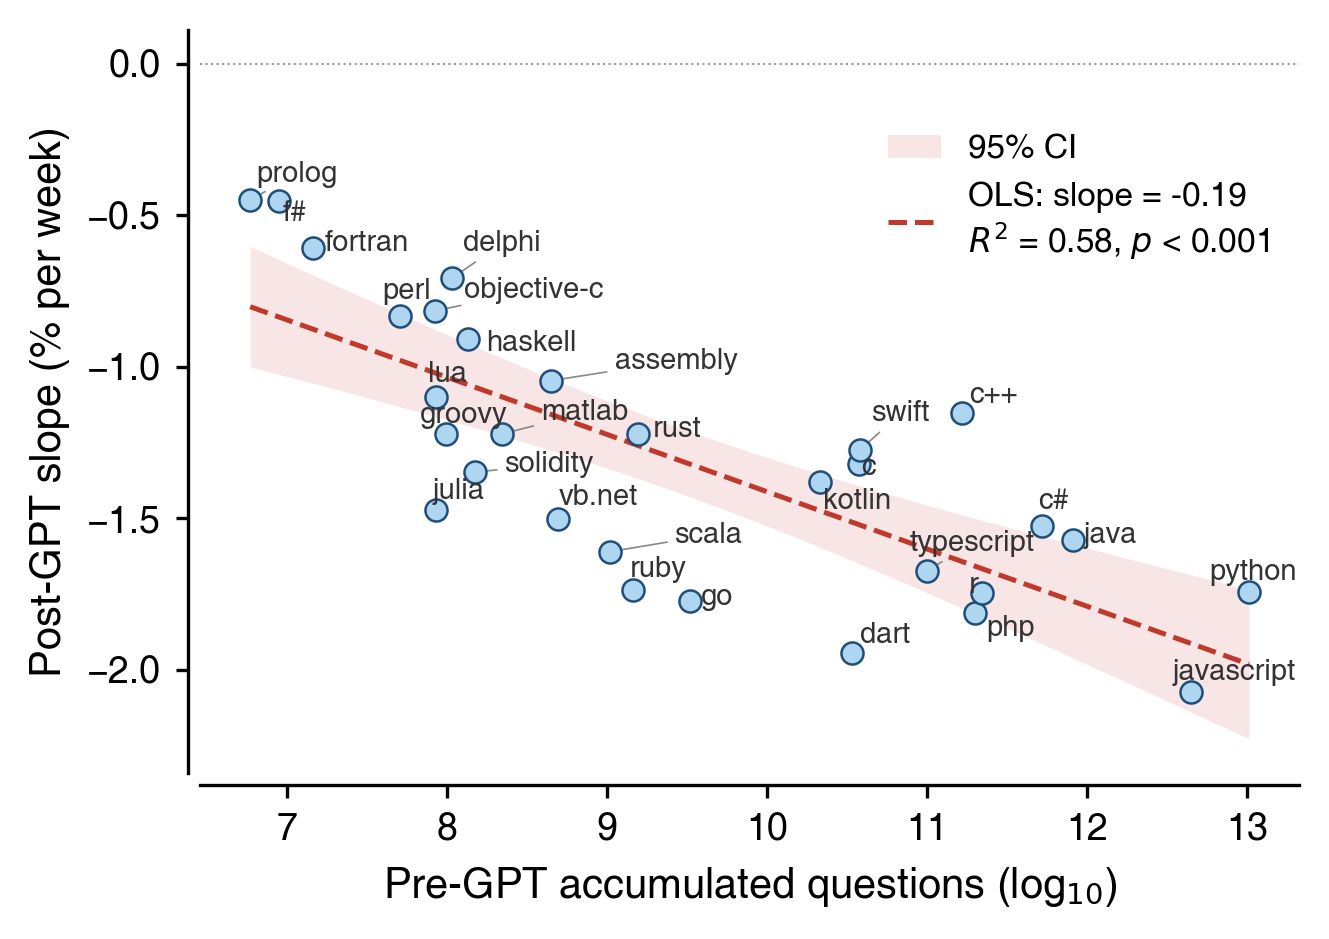

slope=-0.1889, R²=0.5804, p=1.01e-06


In [11]:
# ============================================================
# 4. Plot
# ============================================================
fig, ax = plt.subplots(figsize=(4.5, 3.2), dpi=300)   # 1.5-column

# CI band
ax.fill_between(xx, yy - ci, yy + ci, color='#C0392B', alpha=0.12, lw=0,
                label='95% CI')

# OLS line
ax.plot(xx, yy, color='#C0392B', lw=1.2, ls='--',
        label=f'OLS: slope = {slope:.2f}\n$R^2$ = {r**2:.2f}, $p$ < 0.001'
              if p < 0.001 else
              f'OLS: slope = {slope:.2f}\n$R^2$ = {r**2:.2f}, $p$ = {p:.3f}')

# 0 reference
ax.axhline(0, color='#999', lw=0.5, ls=':', zorder=0)

# Scatter 
ax.scatter(df.loc[:, X_COL], df.loc[:, Y_COL],
           s=28, facecolor='#AED6F1', edgecolor='#1f4e79',
           linewidth=0.6, zorder=3)

# 라벨 — adjustText로 자동 회피 + leader line
texts = []
for _, row in df.iterrows():
    weight = 'normal'
    color  = '#333'
    texts.append(ax.text(row[X_COL], row[Y_COL], row[LABEL_COL],
                         fontsize=7, color=color, weight=weight))

adjust_text(texts, ax=ax,
            expand=(1.2, 1.4),
            arrowprops=dict(arrowstyle='-', color='#888', lw=0.4))

# Spine 정리
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_position(('outward', 3))
ax.spines['bottom'].set_position(('outward', 3))

ax.set_xlabel(XLABEL)
ax.set_ylabel(YLABEL)

# 격자 최소화 (없애거나 아주 옅게)
ax.grid(False)

ax.legend(loc='upper right', bbox_to_anchor=(1, 0.9),
          handlelength=1.6, borderpad=0.4)

plt.tight_layout()
plt.show()
print(f'slope={slope:.4f}, R²={r**2:.4f}, p={p:.2e}')

In [12]:
results = {}
for lang, g in panel.groupby("language"):
    results[lang] = smf.ols("log_y ~ t + post + post_t", data=g).fit(cov_type="HC3")

# 계수와 SE를 데이터프레임으로
summary = pd.DataFrame({
    lang: {
        "post": r.params["post"],
        "post_se": r.bse["post"],
        "post_t": r.params["post_t"],
        "post_t_se": r.bse["post_t"],
    } for lang, r in results.items()
}).T

In [13]:
# 1단계: 언어별 post_t 계수와 SE 모으기
coef_df = pd.DataFrame({
    "language": list(results.keys()),
    "post_t":   [r.params["post_t"] for r in results.values()],
    "post_t_se":[r.bse["post_t"]    for r in results.values()],
})



df = coef_df.merge(slope_summary, on="language")

# 2단계: 메타-회귀
m2 = smf.ols("post_t ~ log_n_docs", data=df).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                 post_t   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     12.40
Date:                Sun, 17 May 2026   Prob (F-statistic):            0.00149
Time:                        14:44:52   Log-Likelihood:                 111.89
No. Observations:                  30   AIC:                            -219.8
Df Residuals:                      28   BIC:                            -217.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0079      0.006      1.296      0.2

In [ ]:
x_vals = df["log_n_docs"]
y_vals = df["post_t"]*100  # weekly % change (negative)
langs = df["language"]
df = pd.DataFrame({'x': x_vals, 'y': y_vals, 'label': langs})
# --------------------------------------------------------------

X_COL     = 'x'
Y_COL     = 'y'
LABEL_COL = 'label'
XLABEL    = r'Pre-GPT accumulated questions (log$_{10}$)'
YLABEL    = 'Post-GPT slope (% per week)'

OUT_PNG = 'figure_scatter.png'
OUT_PDF = 'figure_scatter.pdf'

In [ ]:
x = df[X_COL].values
y = df[Y_COL].values

slope, intercept, r, p, se = stats.linregress(x, y)
xx = np.linspace(x.min(), x.max(), 100)
yy = slope * xx + intercept

# 95% CI band (선형회귀 예측 신뢰구간)
n = len(x)
x_mean = x.mean()
ss_x = np.sum((x - x_mean)**2)
resid = y - (slope * x + intercept)
s_err = np.sqrt(np.sum(resid**2) / (n - 2))
t_val = stats.t.ppf(0.975, n - 2)
ci = t_val * s_err * np.sqrt(1/n + (xx - x_mean)**2 / ss_x)


In [ ]:
# ============================================================
# 4. Plot
# ============================================================
fig, ax = plt.subplots(figsize=(4.5, 3.2), dpi=300)   # 1.5-column

# CI band
ax.fill_between(xx, yy - ci, yy + ci, color='#C0392B', alpha=0.12, lw=0,
                label='95% CI')

# OLS line
ax.plot(xx, yy, color='#C0392B', lw=1.2, ls='--',
        label=f'OLS: slope = {slope:.2f}\n$R^2$ = {r**2:.2f}, $p$ < 0.001'
              if p < 0.001 else
              f'OLS: slope = {slope:.2f}\n$R^2$ = {r**2:.2f}, $p$ = {p:.3f}')

# 0 reference
ax.axhline(0, color='#999', lw=0.5, ls=':', zorder=0)

# Scatter 
ax.scatter(df.loc[:, X_COL], df.loc[:, Y_COL],
           s=28, facecolor='#AED6F1', edgecolor='#1f4e79',
           linewidth=0.6, zorder=3)

# 라벨 — adjustText로 자동 회피 + leader line
texts = []
for _, row in df.iterrows():
    weight = 'normal'
    color  = '#333'
    texts.append(ax.text(row[X_COL], row[Y_COL], row[LABEL_COL],
                         fontsize=7, color=color, weight=weight))

adjust_text(texts, ax=ax,
            expand=(1.2, 1.4),
            arrowprops=dict(arrowstyle='-', color='#888', lw=0.4))

# Spine 정리
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_position(('outward', 3))
ax.spines['bottom'].set_position(('outward', 3))

ax.set_xlabel(XLABEL)
ax.set_ylabel(YLABEL)

# 격자 최소화 (없애거나 아주 옅게)
ax.grid(False)

ax.legend(loc='upper right', bbox_to_anchor=(1, 0.9),
          handlelength=1.6, borderpad=0.4)

plt.tight_layout()
plt.show()
print(f'slope={slope:.4f}, R²={r**2:.4f}, p={p:.2e}')